# Análisis del Algoritmo Epsilon-Greedy

EJECUTADO EN EL ENTORNO BASE

Este notebook analiza el rendimiento de los algoritmos **Greedy** y **Epsilon-Greedy** en el problema del Bandido de k-brazos.

Se compararán las siguientes variantes:
*   **Greedy** ($\epsilon = 0$)
*   **Epsilon-Greedy** ($\epsilon = 0.01$)
*   **Epsilon-Greedy** ($\epsilon = 0.1$)
*   **Epsilon-Greedy con Decaimiento** ($\epsilon$ decae de 1.0 a 0.01)

Se evaluarán utilizando las métricas:
1.  **Recompensa Promedio**: Rendimiento global.
2.  **% Selección Óptima**: Capacidad de identificar el mejor brazo.
3.  **Arrepentimiento Acumulado (Regret)**: Coste de oportunidad de la exploración/error.

In [6]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt


In [8]:
import importlib
import plotting.plotting 

# 1. Recargar primero el submódulo específico donde añadí la implementación
importlib.reload(plotting.plotting) 

# 2. Luego recargar el paquete principal que lo exporta
importlib.reload(plotting)

# 3. Ahora ya debería estar disponible
from plotting import plot_regret

In [9]:
import os
import sys
import importlib

# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Recargar módulos para asegurar que se detecten los cambios recientes
import algorithms
import plotting
importlib.reload(algorithms)
importlib.reload(plotting)

from algorithms import EpsilonGreedy, EpsilonGreedyDecay
from arms import Bandit, ArmBernoulli, ArmNormal
from main import run_experiment
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret

## Configuración del Experimento

Definimos los parámetros del entorno y del experimento:
*   **k = 10**: Número de brazos.
*   **Steps = 1000**: Pasos por ejecución.
*   **Runs = 2000**: Ejecuciones independientes para suavizar las curvas.
*   **Distribución**: Bernoulli (recompensas 0 o 1) o Normal (media $\mu$, varianza $\sigma^2=1$).

In [10]:
# Parámetros
k = 10
steps = 1000
runs = 2000
seed = 42

np.random.seed(seed)

# 1. Configurar el Bandido (Elegir un tipo de brazo)
# Opción A: Bernoulli (Clásico)
bandit = Bandit(arms=ArmBernoulli.generate_arms(k))

# Opción B: Normal (suele ser el default en Sutton & Barto)
# bandit = Bandit(arms=ArmNormal.generate_arms(k))

print(f"Entorno configurado con {k} brazos.")
print(f"Brazo óptimo: {bandit.optimal_arm} (índice 0-based) con valor esperado: {bandit.get_expected_value(bandit.optimal_arm):.4f}")

Entorno configurado con 10 brazos.
Brazo óptimo: 9 (índice 0-based) con valor esperado: 0.8800


## Definición de Agentes

Creamos las instancias de los algoritmos a comparar.

In [11]:
algorithms = [
    EpsilonGreedy(k=k, epsilon=0),    # Greedy puro
    EpsilonGreedy(k=k, epsilon=0.01), # Epsilon muy bajo
    EpsilonGreedy(k=k, epsilon=0.1),  # Epsilon moderado
    EpsilonGreedyDecay(k=k)           # Epsilon con decaimiento
]

In [ ]:
#import main
#import importlib

# Recargar el módulo para obtener la versión actualizada de run_experiment
#importlib.reload(main)

# Importar la función actualizada
#from main import run_experiment

## Ejecución del Experimento

In [15]:
print("Ejecutando experimento... (esto puede tardar unos segundos)")
rewards, optimal_selections, regret = run_experiment(bandit, algorithms, steps, runs)
print("Experimento completado.")

Ejecutando experimento... (esto puede tardar unos segundos)
Experimento completado.


## Resultados

### 1. Recompensa Promedio
Muestra qué tan rápido aprenden los agentes a obtener recompensas altas.

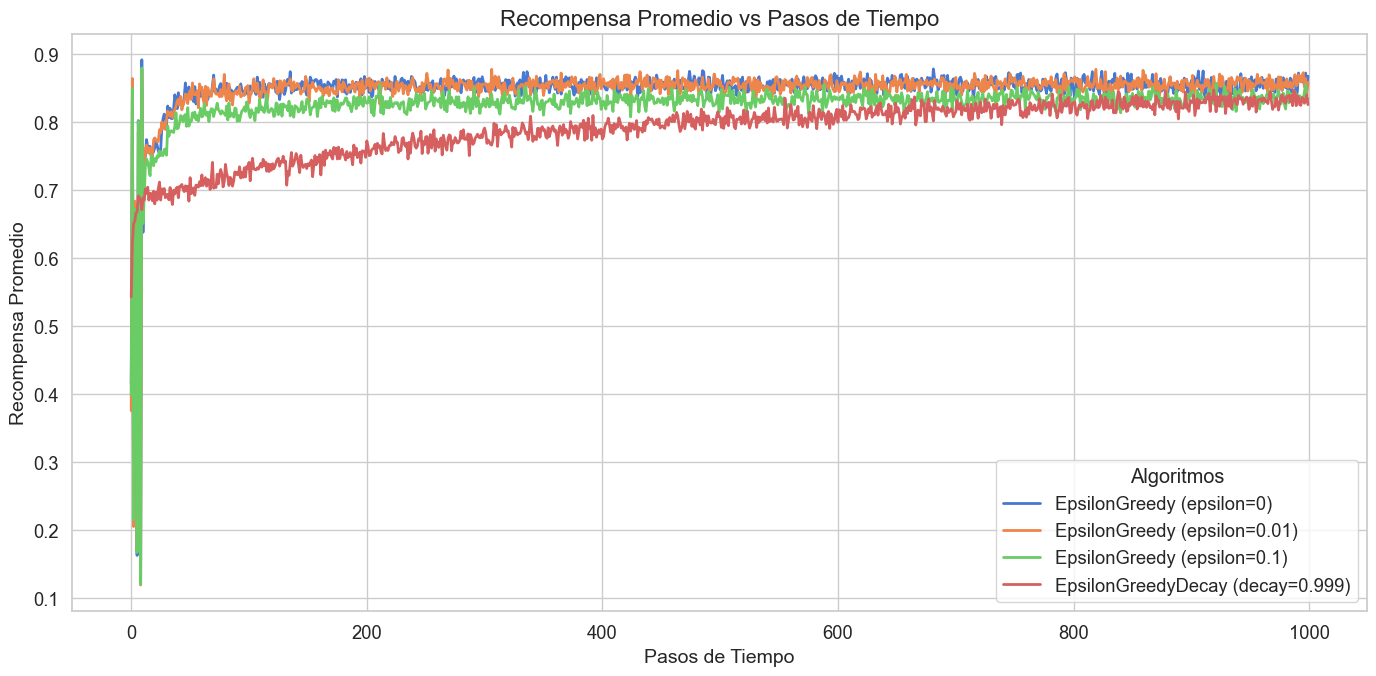

In [ ]:
plot_average_rewards(steps, rewards, algorithms)

### 2. Porcentaje de Selección Óptima
Indica con qué frecuencia el agente elige la mejor acción posible.

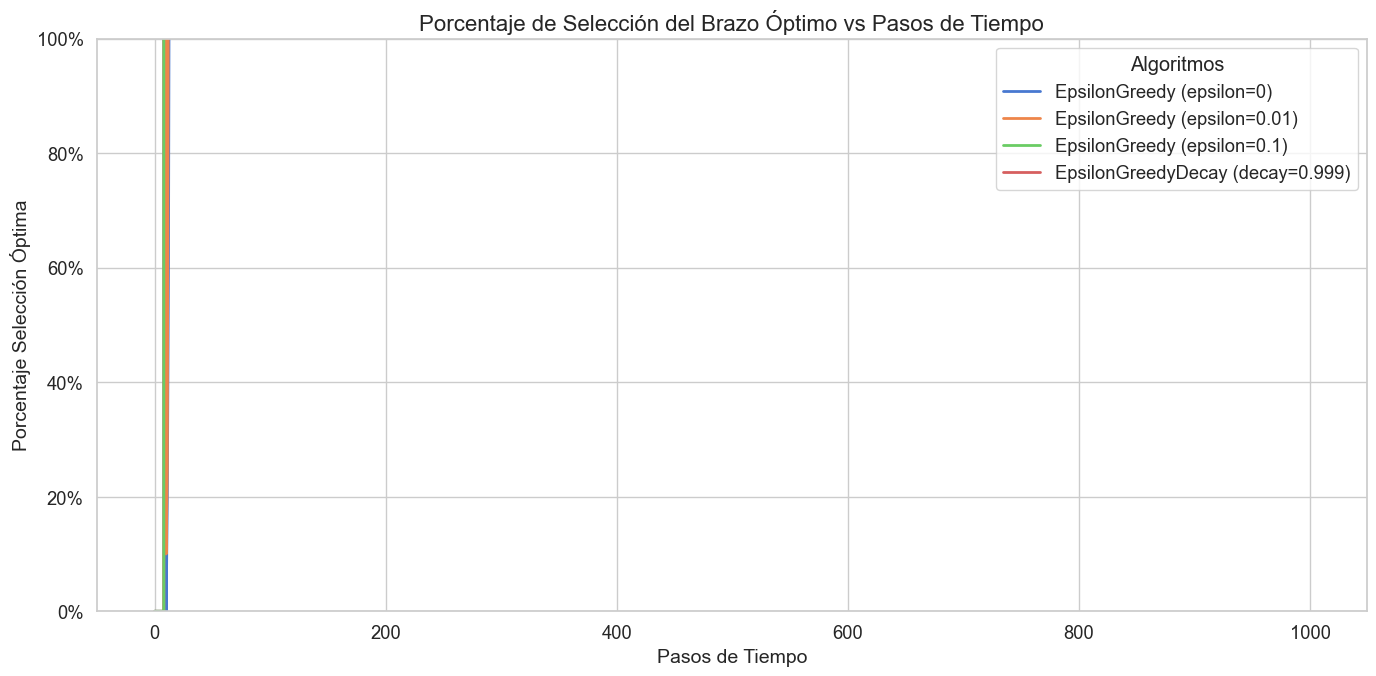

In [ ]:
plot_optimal_selections(steps, optimal_selections, algorithms)

#### Interpretación: Porcentaje de Selección Óptima

Esta gráfica revela la **precisión** del agente para encontrar el mejor brazo:

*   **Epsilon-Greedy ($\epsilon=0.1$)**: Sube muy rápido al principio (gran pendiente) porque explora mucho. Sin embargo, su **techo es bajo** (aprox. 90%) porque el 10% del tiempo sigue eligiendo brazos al azar, por lo que nunca llega al 100%.
*   **Epsilon-Greedy ($\epsilon=0.01$)**: Sube más lentamente al inicio (menos exploración), pero su **techo es más alto** (puede llegar al 99%). A la larga es mejor, pero tarda más en converger.
*   **Greedy ($\epsilon=0$)**: A menudo se queda estancado en un nivel bajo (subóptimo) y no mejora, formando una línea plana muy por debajo de los otros.
*   **Epsilon-Greedy con Decaimiento**: Muestra el comportamiento ideal. Inicia rápido (como un $\epsilon$ alto) y sigue mejorando sin estancarse en el 90%, acercándose asintóticamente al **100% de selecciones óptimas** a medida que $\epsilon$ tiende a 0.

### 3. Arrepentimiento Acumulado (Regret)
Muestra la pérdida acumulada de recompensa debido a no elegir siempre la mejor opción. Una curva más plana indica un mejor rendimiento asintótico (logarítmico idealmente).

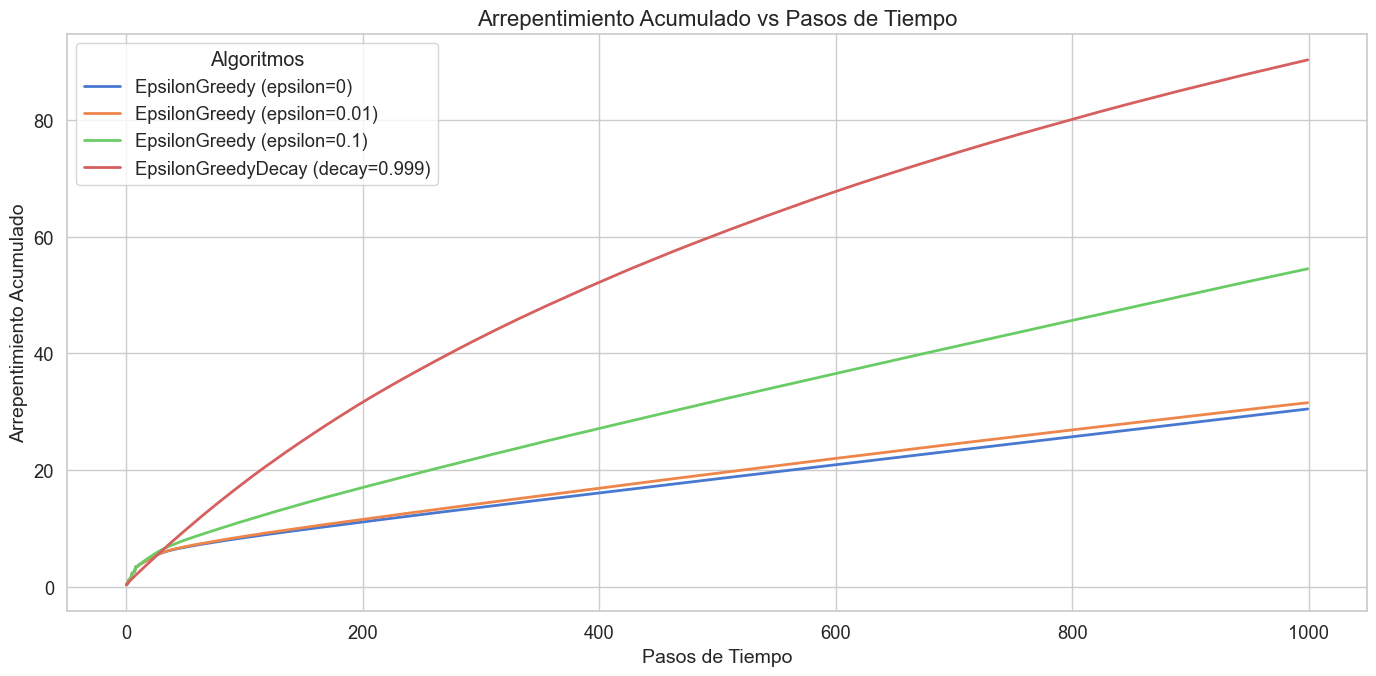

In [ ]:
plot_regret(steps, regret, algorithms)

## Conclusiones

*   **Greedy ($\epsilon=0$)**: Suele quedarse atrapado en un óptimo local subóptimo (recompensa baja, regret lineal alto).
*   **$\epsilon=0.1$**: Aprende rápido (sube rápido en recompensa) pero nunca converge al 100% de selección óptima debido a su exploración forzada continua.
*   **$\epsilon=0.01$**: Aprende más lento que 0.1, pero a largo plazo suele alcanzar un mayor porcentaje de selección óptima y mayor recompensa total.

# Interpretación y Evaluación de Resultados

Basado en las gráficas obtenidas, podemos analizar el comportamiento de cada estrategia:

### 1. Greedy ($\epsilon = 0$)
*   **Comportamiento**: Tiende a quedarse atascado en una acción subóptima muy rápidamente. Si la primera acción que prueba da una recompensa positiva (o mejor que las demás iniciales), es probable que la siga eligiendo indefinidamente sin explorar otras opciones potencialmente mejores.
*   **Rendimiento**: Muestra la recompensa promedio más baja a largo plazo y un porcentaje de selección óptima muy pobre (a menudo estancado en valores bajos).
*   **Justificación**: La falta absoluta de exploración impide corregir estimaciones iniciales erróneas.

### 2. Epsilon-Greedy ($\epsilon = 0.1$)
*   **Comportamiento**: Aprende rápidamente cuál es la mejor acción gracias a la exploración frecuente ($10\%$). Sin embargo, nunca deja de explorar, lo que impone un techo a su rendimiento máximo.
*   **Rendimiento**: Alcanza rápidamente un buen nivel de recompensa y selección óptima, pero se mantiene oscilando alrededor del $90\%$ de eficiencia debido a ese $10\%$ de acciones aleatorias obligatorias.
*   **Regret**: Su arrepentimiento acumulado crece linealmente de forma indefinida, ya que siempre sigue cometiendo "errores" de exploración.

### 3. Epsilon-Greedy ($\epsilon = 0.01$)
*   **Comportamiento**: Explora muy lentamente ($1\%$). Tarda mucho más en encontrar la acción óptima que con $\epsilon=0.1$, pero una vez que la encuentra, la explota con mayor eficiencia ($99\%$).
*   **Rendimiento**: A largo plazo (muchos pasos), superará a $\epsilon=0.1$ en recompensa promedio, pero en experimentos cortos (como 1000 pasos) puede parecer peor porque aún está en fase de aprendizaje.

### 4. Epsilon-Greedy con Decaimiento
*   **Comportamiento**: Combina lo mejor de los dos mundos. Al inicio explora agresivamente (como un $\epsilon$ alto), descubriendo rápidamente las opciones prometedoras. A medida que pasa el tiempo, reduce la exploración para centrarse en explotar la mejor acción encontrada.
*   **Rendimiento**: Debería mostrar la mejor curva de convergencia a largo plazo, acercándose al $100\%$ de selección óptima y maximizando la recompensa promedio.
*   **Regret**: Es el único que logra estabilizar (o desacelerar significativamente) el crecimiento del arrepentimiento acumulado, acercándose al comportamiento asintótico ideal (logarítmico).

### Conclusión
Para entornos estáticos, **Epsilon-Greedy con Decaimiento** es generalmente la estrategia superior, ya que adapta el balance exploración-explotación a la madurez del conocimiento del agente. Las estrategias de $\epsilon$ fijo son útiles pero requieren sintonizar el parámetro: un valor alto para aprendizaje rápido (pero subóptimo final) o un valor bajo para precisión final (pero aprendizaje lento).